In [1]:
!git clone -b transfer-learning https://github.com/KaustubhMukdam/Pneumonia-Detection.git /kaggle/working/Pneumonia-Detection

Cloning into '/kaggle/working/Pneumonia-Detection'...
remote: Enumerating objects: 101, done.
remote: Counting objects: 100% (101/101), done.
remote: Compressing objects: 100% (78/78), done.
remote: Total 101 (delta 41), reused 64 (delta 18), pack-reused 0 (from 0)
Receiving objects: 100% (101/101), 1.55 MiB | 7.97 MiB/s, done.
Resolving deltas: 100% (41/41), done.


# Import Libraries

In [2]:
import os
import random
import hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
)

SEED = 42
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
VALIDATION_FRACTION = 0.15
EPOCHS = 20
MINIMUM_SENSITIVITY = 0.95

random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

print("TensorFlow version:", tf.__version__)
print("Available GPUs:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


# Attached Kaggle Dataset

In [3]:
candidate_roots = []

for train_dir in Path("/kaggle/input").rglob("train"):
    normal_dir = train_dir / "NORMAL"
    pneumonia_dir = train_dir / "PNEUMONIA"

    if normal_dir.is_dir() and pneumonia_dir.is_dir():
        candidate_roots.append(train_dir.parent)

print("Dataset candidates:")

for root in candidate_roots:
    print(root)

if not candidate_roots:
    raise FileNotFoundError(
        "Attach the Chest X-Ray Images (Pneumonia) dataset "
        "using Kaggle's Add Input panel."
    )

DATASET_ROOT = candidate_roots[0]
TRAIN_DIR = DATASET_ROOT / "train"

LABEL_TO_ID = {
    "NORMAL": 0,
    "PNEUMONIA": 1,
}

VALID_EXTENSIONS = {".jpeg", ".jpg"}

assert TRAIN_DIR.exists(), f"Missing directory: {TRAIN_DIR}"

print("\nUsing dataset root:", DATASET_ROOT)

Dataset candidates:
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/__MACOSX/chest_xray

Using dataset root: /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray


# Image Manifest

In [4]:
def build_manifest(split_dir: Path) -> pd.DataFrame:
    records = []

    for class_name, label in LABEL_TO_ID.items():
        class_dir = split_dir / class_name

        for image_path in sorted(class_dir.iterdir()):
            if image_path.suffix.lower() in VALID_EXTENSIONS:
                records.append(
                    {
                        "path": str(image_path),
                        "label": label,
                        "class_name": class_name,
                    }
                )

    return pd.DataFrame(records)

train_full_df = build_manifest(TRAIN_DIR)

print("Raw training images: ", len(train_full_df))
print("\nClass counts: ")
print(train_full_df["class_name"].value_counts())

Raw training images:  5216

Class counts: 
class_name
PNEUMONIA    3875
NORMAL       1341
Name: count, dtype: int64


# Validation split (Duplicate-safe)

In [5]:
def file_sha256(file_path: str) -> str:
    digest = hashlib.sha256()

    with open(file_path, "rb") as file:
        for chunk in iter(lambda: file.read(1024 * 1024), b""):
            digest.update(chunk)

    return digest.hexdigest()


train_full_df["sha256"] = train_full_df["path"].apply(file_sha256)

assert train_full_df.groupby("sha256")["label"].nunique().max() == 1

hash_groups_df = (
    train_full_df.groupby("sha256", as_index=False)
    .agg(
        label=("label", "first"),
        file_count=("path", "size"),
    )
)

train_hashes, val_hashes = train_test_split(
    hash_groups_df["sha256"],
    test_size=VALIDATION_FRACTION,
    random_state=SEED,
    stratify=hash_groups_df["label"],
)

train_df = (
    train_full_df[train_full_df["sha256"].isin(train_hashes)]
    .drop(columns="sha256")
    .reset_index(drop=True)
)

val_df = (
    train_full_df[train_full_df["sha256"].isin(val_hashes)]
    .drop(columns="sha256")
    .reset_index(drop=True)
)

assert set(train_df["path"]).isdisjoint(set(val_df["path"]))

print("Training images:", len(train_df))
print("Validation images:", len(val_df))

print("\nTraining class counts:")
print(train_df["class_name"].value_counts())

print("\nValidation class counts:")
print(val_df["class_name"].value_counts())

Training images: 4432
Validation images: 784

Training class counts:
class_name
PNEUMONIA    3292
NORMAL       1140
Name: count, dtype: int64

Validation class counts:
class_name
PNEUMONIA    583
NORMAL       201
Name: count, dtype: int64


# Tensorflow pipeline
Pixels in [0, 255]. DenseNet preprocessing is doen inside the model

In [6]:
AUTOTUNE = tf.data.AUTOTUNE

def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.io.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMAGE_SIZE, antialias=True)
    image = tf.cast(image, tf.float32)

    return image, tf.cast(label, tf.float32)

def make_dataset(dataframe: pd.DataFrame, training: bool=False):
    paths = dataframe["path"].to_numpy(dtype=str)
    labels = dataframe["label"].to_numpy(dtype=np.float32)

    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))

    if training:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=SEED,
            reshuffle_each_iteration=True,
        )

    dataset = dataset.map(load_image, num_parallel_calls=AUTOTUNE)
    dataset = dataset.batch(BATCH_SIZE).prefetch(AUTOTUNE)

    return dataset

train_ds = make_dataset(train_df, training=True)
val_ds = make_dataset(val_df)
    

I0000 00:00:1786594107.604229      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1786594107.607235      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


# Sanity Check

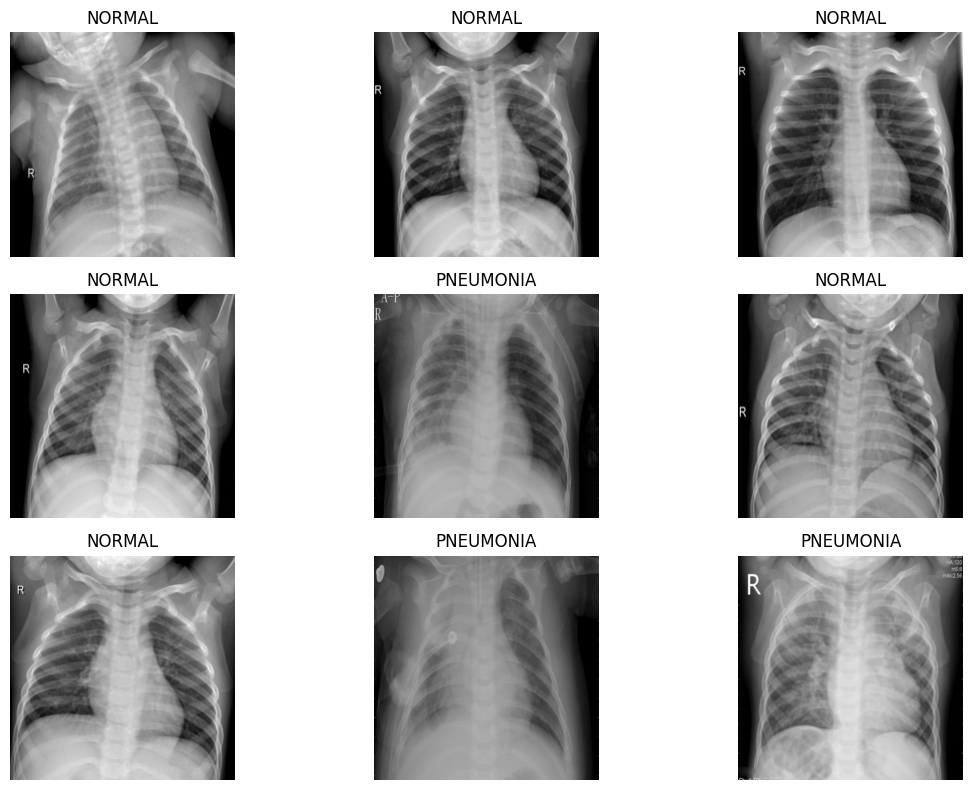

In [7]:
images, labels = next(iter(train_ds))

plt.figure(figsize=(12, 8))

for index in range(9):
    plt.subplot(3, 3, index + 1)
    plt.imshow(images[index].numpy().astype("uint8"))

    class_name = (
        "PNEUMONIA"
        if labels[index].numpy() == 1
        else "NORMAL"
    )

    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

# Conservative Augmentation

In [8]:
augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomRotation(
            factor = 7 / 360,
            fill_mode = "reflect",
        ),
        tf.keras.layers.RandomTranslation(
            height_factor = 0.03,
            width_factor = 0.03,
            fill_mode = "reflect",
        ),
        tf.keras.layers.RandomZoom(
            height_factor = 0.05,
            width_factor = 0.05,
            fill_mode = "reflect",
        ),
    ],
    name = "augmentation",
)

# Build Frozen DenseNet121

In [9]:
base_model = tf.keras.applications.DenseNet121(
    include_top = False,
    weights = "imagenet",
    input_shape = (224, 224, 3),
    pooling = "avg",
)

base_model.trainable = False

inputs = tf.keras.Input(
    shape = (224, 224, 3),
    name = "chest_xray",
)

x = augmentation(inputs)

x = tf.keras.applications.densenet.preprocess_input(x)

x = base_model(x, training = False)

x = tf.keras.layers.Dropout(0.30)(x)

outputs = tf.keras.layers.Dense(
    1,
    activation="sigmoid",
    name="pneumonia_probability",
)(x)

densenet_model = tf.keras.Model(
    inputs = inputs,
    outputs = outputs,
    name = "densenet121_frozen",
)

densenet_model.compile(
    optimizer = tf.keras.optimizers.Adam(
        learning_rate = 3e-4,
    ),
    loss = tf.keras.losses.BinaryCrossentropy(),
    metrics = [
        tf.keras.metrics.BinaryAccuracy(name = "accuracy"),
        tf.keras.metrics.Precision(name = "precision"),
        tf.keras.metrics.Recall(name = "recall"),
        tf.keras.metrics.AUC(name = "roc_auc", curve = "ROC"),
    ],
)

densenet_model.summary()

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "densenet121_frozen"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ chest_xray (InputLayer)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add (Add)                       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 1024)           │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pneumonia_probability (Dense)   │ (None, 1)              │         1,025 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,038,529 (26.85 MB)

 Trainable params: 1,025 (4.00 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

# Training Callbacks

In [10]:
CHECKPOINT_PATH = (
    "/kaggle/working/densenet121_frozen_best.keras"
)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=CHECKPOINT_PATH,
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        verbose=1,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=5,
        restore_best_weights=True,
        verbose=1,
    ),
]

# Train

In [11]:
history = densenet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step - accuracy: 0.6091 - loss: 0.7235 - precision: 0.7523 - recall: 0.7126 - roc_auc: 0.5479
Epoch 1: val_loss improved from None to 0.41986, saving model to /kaggle/working/densenet121_frozen_best.keras

Epoch 1: finished saving model to /kaggle/working/densenet121_frozen_best.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 56s 275ms/step - accuracy: 0.7010 - loss: 0.6009 - precision: 0.7640 - recall: 0.8645 - roc_auc: 0.6163 - val_accuracy: 0.7819 - val_loss: 0.4199 - val_precision: 0.7739 - val_recall: 0.9983 - val_roc_auc: 0.8917
Epoch 2/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step - accuracy: 0.8089 - loss: 0.4255 - precision: 0.8191 - recall: 0.9560 - roc_auc: 0.8346
Epoch 2: val_loss improved from 0.41986 to 0.30527, saving model to /kaggle/working/densenet121_frozen_best.keras

Epoch 2: finished saving model to /kaggle/working/densenet121_frozen_best.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 34s 243ms/step - accuracy: 0.8168 - loss: 0.4041 - preci

# Training curves

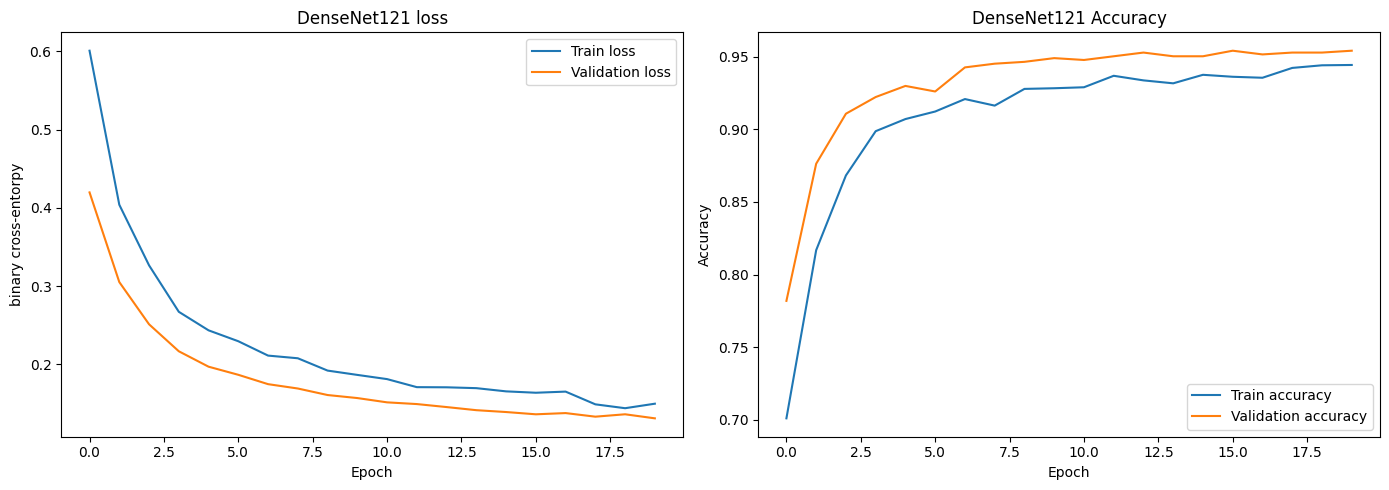

In [12]:
history_df = pd.DataFrame(history.history)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_df["loss"], label="Train loss")
axes[0].plot(history_df["val_loss"], label="Validation loss")
axes[0].set_title("DenseNet121 loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("binary cross-entorpy")
axes[0].legend()

axes[1].plot(history_df["accuracy"], label="Train accuracy")
axes[1].plot(history_df["val_accuracy"], label="Validation accuracy")
axes[1].set_title("DenseNet121 Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

# Load best checkpoint

In [13]:
best_densenet_model = tf.keras.models.load_model(
    CHECKPOINT_PATH,
)

# Validation metrics at threshold 0.50

In [14]:
validation_probabilities = (
    best_densenet_model.predict(val_ds, verbose=1)
    .ravel()
)

validation_labels = val_df["label"].to_numpy()

default_predictions = (
    validation_probabilities >= 0.50
).astype(int)

tn, fp, fn, tp = confusion_matrix(
    validation_labels,
    default_predictions,
    labels=[0, 1],
).ravel()

default_validation_results = {
    "threshold" : 0.50,
    "accuracy" : accuracy_score(
        validation_labels,
        default_predictions,
    ),
    "precision" : precision_score(
        validation_labels,
        default_predictions,
        zero_division = 0,
    ),
    "sensitivity/recall" : recall_score(
        validation_labels,
        default_predictions,
        zero_division = 0,
    ),
    "specificity" : tn / (tn + fp),
    "f1_score" : f1_score(
        validation_labels,
        default_predictions,
        zero_division = 0,
    ),
    "orc-auc" : roc_auc_score(
        validation_labels,
        validation_probabilities,
    ),
    "true_negatives" : tn,
    "false_positives" : fp,
    "false_negatives" : fn,
    "true_positives" : tp,
}

pd.Series(default_validation_results).round(1)

25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 310ms/step


threshold               0.5
accuracy                1.0
precision               1.0
sensitivity/recall      1.0
specificity             0.9
f1_score                1.0
orc-auc                 1.0
true_negatives        183.0
false_positives        18.0
false_negatives        18.0
true_positives        565.0
dtype: float64

# Threshold selection on validation dataset

In [15]:
threshold_rows = []

for threshold in np.arange(0.10, 0.91, 0.01):
    predictions = (
        validation_probabilities >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        validation_labels,
        predictions,
        labels=[0, 1],
    ).ravel()

    threshold_rows.append(
        {
            "threshold" : round(float(threshold), 2),
            "sensitivity/recall" : recall_score(
                validation_labels,
                predictions,
                zero_division=0,
            ),
            "specificity" : tn / (tn + fp),
            "precision" : precision_score(
                validation_labels,
                predictions,
                zero_division=0,
            ),
            "f1_score" : f1_score(
                validation_labels,
                predictions,
                zero_division=0,
            ),
            "false_negatives" : fn,
            "false_positives" : fp,
        }
    )

threshold_results = pd.DataFrame(threshold_rows)

eligible_thresholds = threshold_results[
    threshold_results["sensitivity/recall"] >= MINIMUM_SENSITIVITY
]

if eligible_thresholds.empty:
    raise ValueError(
        "No threshold meets the selected minimum sensitivity/recall"
    )

selected_threshold_row = (
    eligible_thresholds
    .sort_values("threshold", ascending=False)
    .iloc[0]
)

selected_threshold_row

threshold              0.670000
sensitivity/recall     0.950257
specificity            0.955224
precision              0.984014
f1_score               0.966841
false_negatives       29.000000
false_positives        9.000000
Name: 57, dtype: float64

# Validation report at selected threshold

Selected Validation threshold: 0.67
              precision    recall  f1-score   support

      NORMAL        0.9       1.0       0.9       201
   PNEUMONIA        1.0       1.0       1.0       583

    accuracy                            1.0       784
   macro avg        0.9       1.0       0.9       784
weighted avg        1.0       1.0       1.0       784



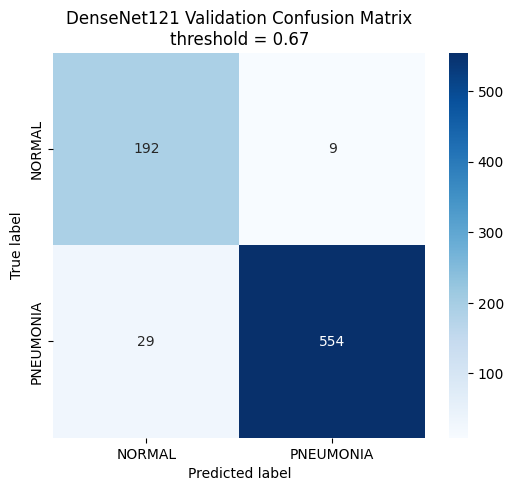

In [16]:
SELECTED_THRESHOLD = selected_threshold_row["threshold"]

selected_predictions = (
    validation_probabilities >= SELECTED_THRESHOLD
).astype(int)

print(f"Selected Validation threshold: {SELECTED_THRESHOLD:.2f}")

print(
    classification_report(
        validation_labels,
        selected_predictions,
        target_names=["NORMAL", "PNEUMONIA"],
        digits=1,
        zero_division=0
    )
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    confusion_matrix(
        validation_labels,
        selected_predictions,
    ),
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["NORMAL", "PNEUMONIA"],
    yticklabels=["NORMAL", "PNEUMONIA"],
)

plt.title(
    "DenseNet121 Validation Confusion Matrix\n"
    f"threshold = {SELECTED_THRESHOLD:.2f}"
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show()

# Validation ROC curve

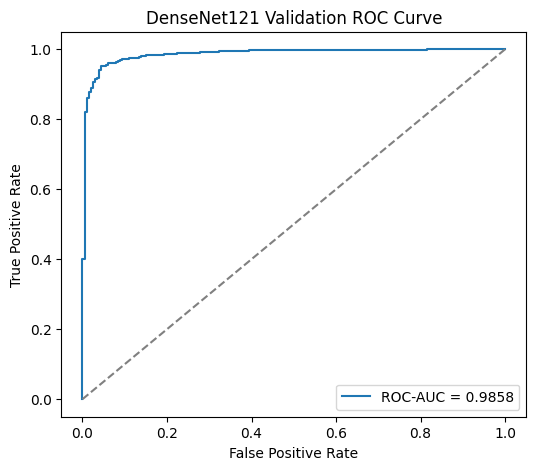

In [17]:
false_positive_rate, true_positive_rate, _ = roc_curve(
    validation_labels,
    validation_probabilities,
)

validation_roc_auc = roc_auc_score(
    validation_labels,
    validation_probabilities,
)

plt.figure(figsize=(6, 5))

plt.plot(
    false_positive_rate,
    true_positive_rate,
    label=f"ROC-AUC = {validation_roc_auc:.4f}",
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
)

plt.title("DenseNet121 Validation ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# Save Outputs

In [18]:
history_df.to_csv(
    "/kaggle/working/densenet121_history.csv",
    index=False,
)

threshold_results.to_csv(
    "/kaggle/working/densenet121_threshold_analysis.csv",
    index=False,
)

pd.DataFrame(
    [default_validation_results]
).to_csv(
    "/kaggle/working/densenet121_validation_metrics.csv",
    index=False,
)

In [19]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
)

# Predict only on the validation dataset.
validation_probabilities = densenet_model.predict(
    val_ds,
    verbose=1,
).ravel()

# Labels must come from the same validation dataframe used to create val_ds.
validation_labels = val_df["label"].to_numpy()

def evaluate_at_threshold(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1],
    ).ravel()

    results = {
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "sensitivity_recall": recall_score(y_true, y_pred, zero_division=0),
        "specificity": tn / (tn + fp),
        "f1_score": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "true_negatives": tn,
        "false_positives": fp,
        "false_negatives": fn,
        "true_positives": tp,
    }

    return pd.Series(results)

print("DenseNet121 validation metrics at threshold = 0.50")
display(evaluate_at_threshold(validation_labels, validation_probabilities, 0.50))

print("DenseNet121 validation metrics at threshold = 0.67")
display(evaluate_at_threshold(validation_labels, validation_probabilities, 0.67))

25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 307ms/step
DenseNet121 validation metrics at threshold = 0.50


threshold               0.500000
accuracy                0.954082
precision               0.969125
sensitivity_recall      0.969125
specificity             0.910448
f1_score                0.969125
roc_auc                 0.985800
true_negatives        183.000000
false_positives        18.000000
false_negatives        18.000000
true_positives        565.000000
dtype: float64

DenseNet121 validation metrics at threshold = 0.67


threshold               0.670000
accuracy                0.951531
precision               0.984014
sensitivity_recall      0.950257
specificity             0.955224
f1_score                0.966841
roc_auc                 0.985800
true_negatives        192.000000
false_positives         9.000000
false_negatives        29.000000
true_positives        554.000000
dtype: float64

# Evaluation on Test set

In [20]:
TEST_DIR = DATASET_ROOT / "test"

test_df = build_manifest(TEST_DIR)

test_ds = make_dataset(
    test_df,
    training=False,
)

In [23]:
test_df

,path,label,class_name
0,/kaggle/input/datasets/paultimothymooney/chest...,0,NORMAL
1,/kaggle/input/datasets/paultimothymooney/chest...,0,NORMAL
2,/kaggle/input/datasets/paultimothymooney/chest...,0,NORMAL
3,/kaggle/input/datasets/paultimothymooney/chest...,0,NORMAL
4,/kaggle/input/datasets/paultimothymooney/chest...,0,NORMAL
...,...,...,...
619,/kaggle/input/datasets/paultimothymooney/chest...,1,PNEUMONIA
620,/kaggle/input/datasets/paultimothymooney/chest...,1,PNEUMONIA
621,/kaggle/input/datasets/paultimothymooney/chest...,1,PNEUMONIA
622,/kaggle/input/datasets/paultimothymooney/chest...,1,PNEUMONIA


# Verified Validation results

In [24]:
best_densenet_model = tf.keras.models.load_model(
    CHECKPOINT_PATH
)

test_probabilities = best_densenet_model.predict(
    test_ds,
    verbose=1,
).ravel()

test_labels = test_df["label"].to_numpy()

20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 326ms/step


# Evaluate on pre-selected threshold

In [26]:
FINAL_THRESHOLD = 0.67

test_results = evaluate_at_threshold(
    test_labels,
    test_probabilities,
    FINAL_THRESHOLD,
)

display(test_results)

threshold               0.670000
accuracy                0.857372
precision               0.835189
sensitivity_recall      0.961538
specificity             0.683761
f1_score                0.893921
roc_auc                 0.952213
true_negatives        160.000000
false_positives        74.000000
false_negatives        15.000000
true_positives        375.000000
dtype: float64

# Classification report and Confusion matrix

              precision    recall  f1-score   support

      NORMAL       0.91      0.68      0.78       234
   PNEUMONIA       0.84      0.96      0.89       390

    accuracy                           0.86       624
   macro avg       0.87      0.82      0.84       624
weighted avg       0.86      0.86      0.85       624



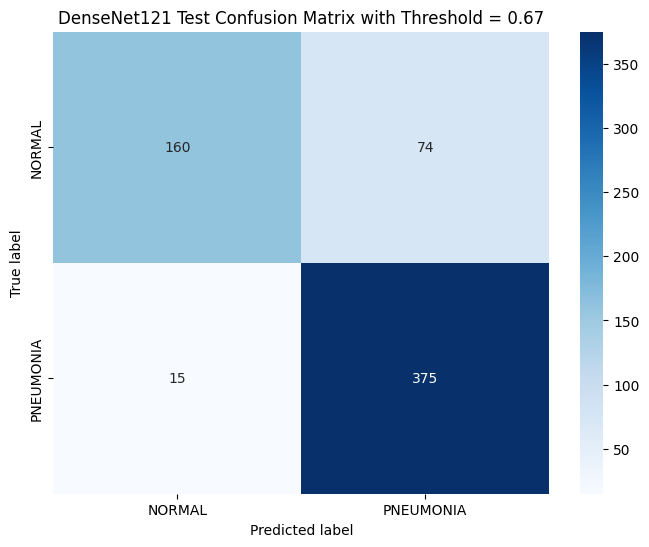

In [28]:
test_predictions = (
    test_probabilities >= FINAL_THRESHOLD
).astype(int)

print(
    classification_report(
        test_labels,
        test_predictions,
        target_names=["NORMAL", "PNEUMONIA"],
        zero_division=0,
    )
)

cm= confusion_matrix(
    test_labels,
    test_predictions,
    labels=[0, 1],
)

plt.figure(figsize=(8,6))
# plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["NORMAL", "PNEUMONIA"],
    yticklabels=["NORMAL", "PNEUMONIA"],
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title(f"DenseNet121 Test Confusion Matrix with Threshold = {FINAL_THRESHOLD}")

plt.show()